In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [2]:
import h5py
import os
import re

folder = "results"   # your results folder
all_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("seed"):
        filepath = os.path.join(folder, filename)
        print(filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']
            specseed = f['Order']['Observational Parameters'].attrs['seed']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            all_data[(i, snr, nspec, specseed)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]



results/seededntemp_i0_snr25nspec10specseed4.h5
results/seededntemp_i0_snr25nspec50specseed2.h5
results/seededntemp_i0_snr25nspec20specseed2.h5
results/seededntemp_i0_snr25nspec30specseed3.h5
results/seededntemp_i0_snr25nspec40specseed3.h5
results/seededntemp_i0_snr25nspec60specseed0.h5
results/seededntemp_i0_snr25nspec10specseed0.h5
results/seededntemp_i0_snr25nspec30specseed2.h5
results/seededntemp_i0_snr25nspec40specseed2.h5
results/seededntemp_i0_snr25nspec60specseed1.h5
results/seededntemp_i0_snr25nspec10specseed1.h5
results/seededntemp_i0_snr25nspec50specseed3.h5
results/seededntemp_i0_snr25nspec20specseed3.h5
results/seededntemp_i0_snr50nspec70specseed0.h5
results/seededntemp_i0_snr10nspec40specseed3.h5
results/seededntemp_i0_snr10nspec30specseed3.h5
results/seededntemp_i0_snr50nspec20specseed3.h5
results/seededntemp_i0_snr10nspec10specseed0.h5
results/seededntemp_i0_snr50nspec50specseed3.h5
results/seededntemp_i0_snr10nspec60specseed0.h5
results/seededntemp_i0_snr50nspec70specs

In [3]:
import numpy as np
def rmse_no_outliers(pred, true, pct=99):
    """Compute RMSE after removing large outliers in residuals."""
    err = pred - true
    thresh = np.percentile(np.abs(err), pct)
    mask = np.abs(err) <= thresh
    return np.sqrt(np.mean(err[mask]**2))

final_results = {}

for (i, snr, nspec, specseed), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_rmse": [],
        "template_rmse": [],
        "mala_rmse": [],
        "prior_rmse": [],
        "intrinsic_unc": [],
        "template_unc": [],
        "mala_unc": [],
        "prior_unc": [],
        "intrinsic_z_mean": [],
        "intrinsic_z_std": [],
        "template_z_mean": [],
        "template_z_std": [],
        "mala_z_mean": [],
        "mala_z_std": [],
        "prior_z_mean": [],
        "prior_z_std": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        prior = group["prior_rv"][()]
        mala = group["mala_samples"][()]
        # Point estimates for mala
        mala_mean = mala.mean(axis=0).mean(axis=0)#[0]
        mala_std = mala.std(axis=0).mean(axis=0)#[0]

        # --- RMSE ---
        results["intrinsic_rmse"].append(rmse_no_outliers(intrinsic, true))
        results["prior_rmse"].append(rmse_no_outliers(prior, true))
        results["template_rmse"].append(rmse_no_outliers(template, true))
        results["mala_rmse"].append(rmse_no_outliers(mala_mean, true))


        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        prior_unc = group["prior_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        prior_z = (prior - true) / prior_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        

        results["intrinsic_z_mean"].append(intrinsic_z.mean())
        results["intrinsic_z_std"].append(intrinsic_z.std())
        results["intrinsic_unc"].append(intrinsic_unc.mean())
        results["template_unc"].append(template_unc.mean())
        results["prior_unc"].append(prior_unc.mean())
        results["mala_unc"].append(mala_std.mean())
        results["template_z_mean"].append(template_z.mean())
        results["template_z_std"].append(template_z.std())
        results["mala_z_mean"].append(mala_z.mean())
        results["mala_z_std"].append(mala_z.std())
        results["prior_z_mean"].append(prior_z.mean())
        results["prior_z_std"].append(prior_z.std())

    # --- Average across all seeds ---
    final_results[(i, snr, nspec, specseed)] = {k: np.mean(v) for k, v in results.items()}


In [4]:
import pandas as pd

# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec","specseed"])
df_rmse = df_results.reset_index()

# df_results[(df_results['i']==6)&(df_results['nspec']==10)]
df_rmse

,i,snr,nspec,specseed,intrinsic_rmse,template_rmse,mala_rmse,prior_rmse,intrinsic_unc,template_unc,mala_unc,prior_unc,intrinsic_z_mean,intrinsic_z_std,template_z_mean,template_z_std,mala_z_mean,mala_z_std,prior_z_mean,prior_z_std
0,0,25,10,4,25.444713,46.962471,38.959304,38.881031,28.800205,28.694024,29.179565,29.429533,-0.036627,0.916899,0.454845,1.696638,0.977775,0.970054,0.965323,0.945757
1,0,25,50,2,25.444713,29.980656,26.334202,26.204442,28.800205,29.054381,28.640676,28.934336,-0.036627,0.916899,-0.047556,1.067650,-0.012864,0.970502,-0.010676,0.945169
2,0,25,20,2,25.444713,35.364609,27.766243,27.702950,28.800205,28.969799,28.932959,29.002047,-0.036627,0.916899,-0.029158,1.291859,0.317631,0.954453,0.314564,0.936233
3,0,25,30,3,25.444713,32.036199,25.987074,25.978370,28.800205,29.122574,29.031810,29.013827,-0.036627,0.916899,0.185409,1.129286,0.101048,0.933854,0.106390,0.923184
4,0,25,40,3,25.444713,29.722819,25.909951,25.932747,28.800205,29.018624,28.920915,28.979089,-0.036627,0.916899,-0.077487,1.064609,-0.021135,0.945975,-0.013070,0.931534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0,25,20,1,25.444713,35.893466,27.104631,27.187386,28.800205,28.987872,28.976744,29.019210,-0.036627,0.916899,0.032778,1.333280,0.270371,0.944574,0.266451,0.930780
95,0,25,30,0,25.444713,32.016920,26.121433,26.106273,28.800205,29.044081,28.967455,29.013128,-0.036627,0.916899,-0.099728,1.152612,-0.072630,0.943173,-0.069496,0.932377
96,0,25,40,0,25.444713,29.167365,26.503861,26.498328,28.800205,29.051328,28.917241,29.011655,-0.036627,0.916899,-0.192624,1.042000,-0.176419,0.954250,-0.168651,0.937196
97,0,25,60,3,25.444713,27.764247,25.633685,25.640644,28.800205,28.984120,28.914242,28.898736,-0.036627,0.916899,0.019326,0.991468,-0.071599,0.937776,-0.061263,0.921673


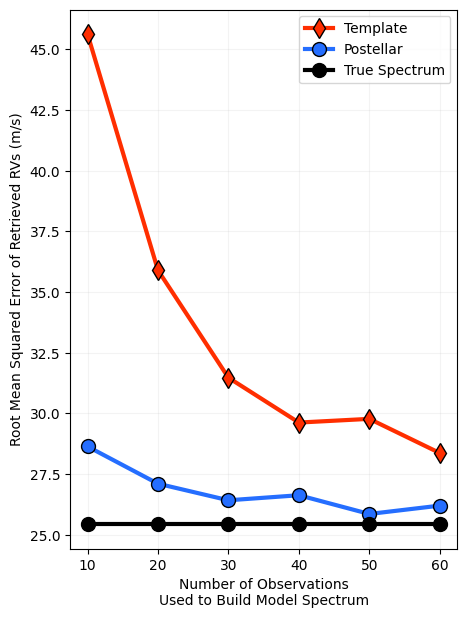

In [5]:
df_snr = df_rmse[df_rmse['snr']==25] 
df_snr = df_snr[df_snr['specseed']==1] 
df_snr_sorted = df_snr.sort_values(['nspec']) 
template_color = "#FF2E00" # bright orange 
postellar_color = "#256EFF" 
plt.figure(figsize=(5,7)) 
plt.plot(df_snr_sorted['nspec'],df_snr_sorted['template_rmse'],c=template_color,marker="d",ms=10,mec="k",lw=3,label="Template") 
plt.plot(df_snr_sorted['nspec'],df_snr_sorted['mala_rmse'],c=postellar_color,marker="o",ms=10,mec="k",lw=3,label="Postellar") 
plt.plot(df_snr_sorted['nspec'],df_snr_sorted['intrinsic_rmse'],c="k",marker="o",ms=10,mec="k",lw=3,label="True Spectrum") 
plt.ylabel("Root Mean Squared Error of Retrieved RVs (m/s)") 
plt.xlabel("Number of Observations\nUsed to Build Model Spectrum") 
plt.legend(loc="upper right") 
plt.grid(alpha=0.15)

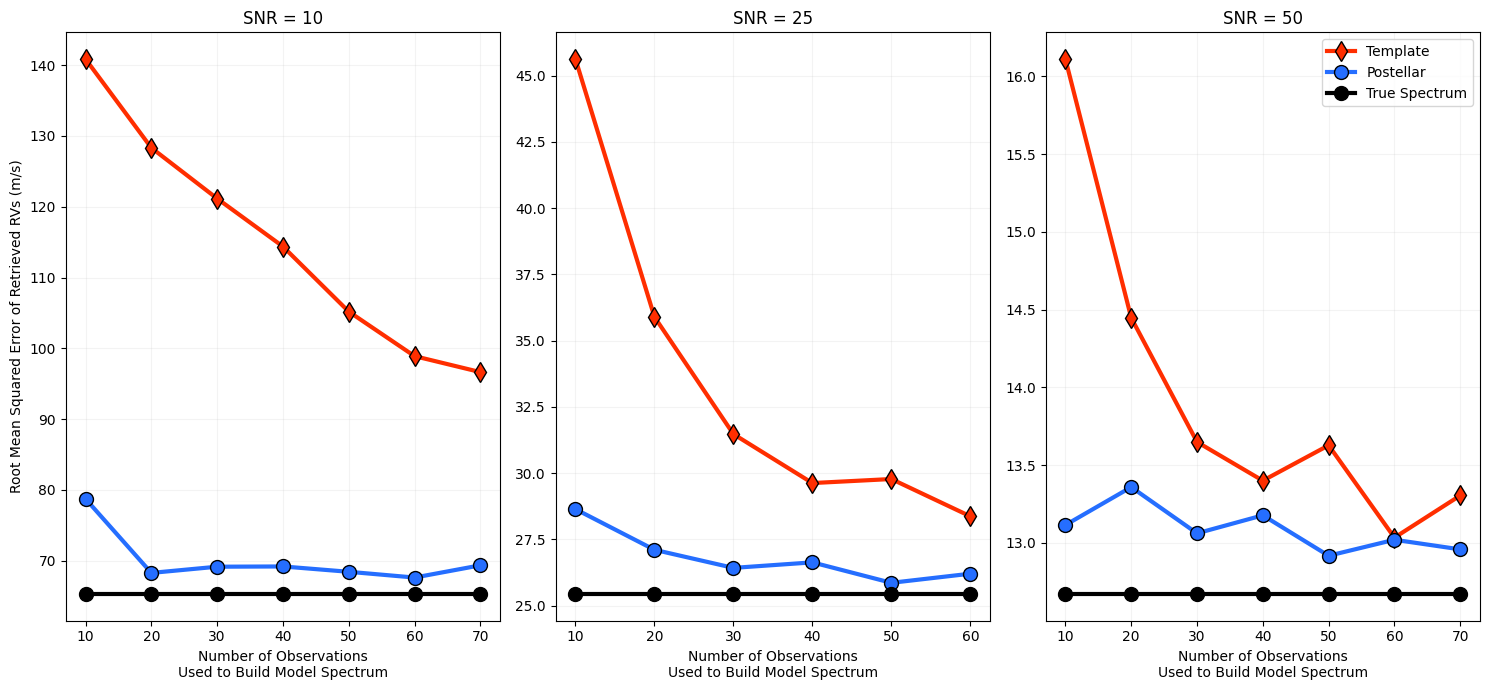

In [6]:
import matplotlib.pyplot as plt

snr_values = [10, 25, 50]

template_color = "#FF2E00"   # bright orange (warm)
postellar_color = "#256EFF"  # bright cool-toned blue

fig, axs = plt.subplots(1, 3, figsize=(15, 7))

for ax, snr in zip(axs, snr_values):
    df_snr = df_rmse[df_rmse['snr'] == snr].sort_values(['nspec'])
    df_snr = df_snr[df_snr['specseed']==1] 

    ax.plot(df_snr['nspec'], df_snr['template_rmse'],
            c=template_color, marker="d", ms=10, mec="k", lw=3,
            label="Template")

    ax.plot(df_snr['nspec'], df_snr['mala_rmse'],
            c=postellar_color, marker="o", ms=10, mec="k", lw=3,
            label="Postellar")

    ax.plot(df_snr['nspec'], df_snr['intrinsic_rmse'],
            c="k", marker="o", ms=10, mec="k", lw=3,
            label="True Spectrum")

    ax.set_title(f"SNR = {snr}", fontsize=12)
    ax.grid(alpha=0.15)
#     ax.set_yscale("log")

# Shared y-label
axs[0].set_ylabel("Root Mean Squared Error of Retrieved RVs (m/s)")

# Shared x-label on the middle plot (or all three)
for ax in axs:
    ax.set_xlabel("Number of Observations\nUsed to Build Model Spectrum")

# One legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
axs[2].legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()



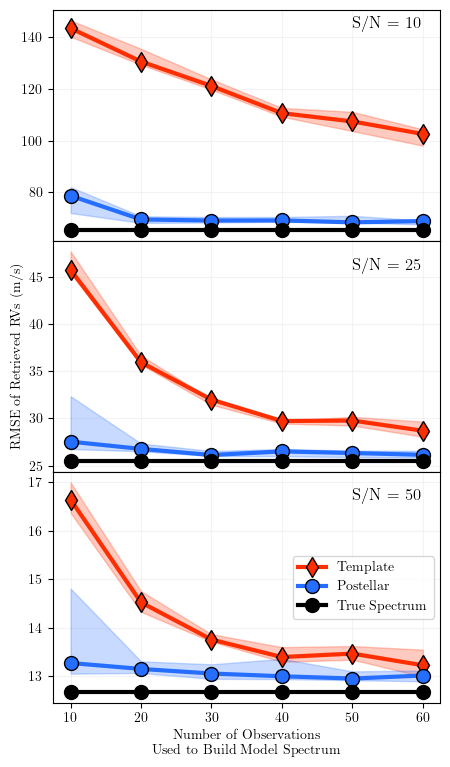

In [11]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
df_rmse = df_rmse[df_rmse['nspec']<65]
snr_values = [10, 25, 50]

template_color = "#FF2E00"   # bright warm tone
postellar_color = "#256EFF"  # bright cool-toned green/blue

fig, axs = plt.subplots(3,1, figsize=(5,9),sharex=True)
fig.subplots_adjust(hspace=0,wspace=0)

for ax, snr in zip(axs, snr_values):
    df_snr = df_rmse[df_rmse['snr'] == snr].sort_values(['nspec'])

    # --- GROUP BY nspec AND COMPUTE PERCENTILES ---
    grouped = df_snr.groupby("nspec")
    nspec_values = grouped["nspec"].first().values

    def pct(col):
        """Return 16th, 50th (median), 84th percentiles for a column."""
        p16 = grouped[col].quantile(0.16).values
        p50 = grouped[col].quantile(0.50).values
        p84 = grouped[col].quantile(0.84).values
        return p16, p50, p84

    t16, t50, t84 = pct("template_rmse")
    m16, m50, m84 = pct("mala_rmse")
    i16, i50, i84 = pct("intrinsic_rmse")

    # --- TEMPLATE ---
    ax.plot(nspec_values, t50,
            c=template_color, marker="d", ms=10, mec="k", lw=3,
            label="Template")

    ax.fill_between(nspec_values, t16, t84,
                    color=template_color, alpha=0.25)

    # --- MALA ---
    ax.plot(nspec_values, m50,
            c=postellar_color, marker="o", ms=10, mec="k", lw=3,
            label="Postellar")

    ax.fill_between(nspec_values, m16, m84,
                    color=postellar_color, alpha=0.25)

    # --- INTRINSIC ---
    ax.plot(nspec_values, i50,
            c="k", marker="o", ms=10, mec="k", lw=3,
            label="True Spectrum")

    ax.fill_between(nspec_values, i16, i84,
                    color="gray", alpha=0.25)

    ax.text(50,t50[0],f"S/N = {snr}", fontsize=12)
    ax.grid(alpha=0.15)


# Shared y-label
# axs[0].set_ylabel("RMSE of Retrieved RVs (m/s)")
axs[1].set_ylabel("RMSE of Retrieved RVs (m/s)")
# axs[2].set_ylabel("RMSE of Retrieved RVs (m/s)")


# Shared x-label
for ax in axs[-1:]:
    ax.set_xlabel("Number of Observations\nUsed to Build Model Spectrum")

# One legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
axs[2].legend(handles, labels, loc="center right")

# plt.tight_layout()
plt.savefig("num_observations.pdf",dpi=300)
plt.show()


In [8]:
import numpy as np

final_results = {}

for (i, snr, nspec, specseed), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_z": [],
        "template_z": [],
        "mala_z": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        mala = group["mala_samples"][()]   # shape: (n_samples,)
        # Point estimates for mala
        mala_mean = mala.mean(axis=(0,1))#[0]
        mala_std = mala.std(axis=(0,1))#.mean(axis=0)#[0]

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##

        results["intrinsic_z"].append(intrinsic_z)
        results["template_z"].append(template_z)
        results["mala_z"].append(mala_z)

# --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: np.std(v) for k, v in results.items()}


In [9]:
# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec"])
df_results = df_results.reset_index()
df_results = df_results.sort_values(by=['snr', 'nspec'])
df_results

,i,snr,nspec,intrinsic_z,template_z,mala_z
10,0,10,10,0.955440,4.090495,0.995383
13,0,10,20,0.955440,2.926173,0.972127
8,0,10,30,0.955440,2.371444,1.020312
7,0,10,40,0.955440,2.021274,0.993954
15,0,10,50,0.955440,1.796285,1.005783
12,0,10,60,0.955440,1.590576,0.985986
17,0,10,70,0.955440,1.581732,0.993522
0,0,25,10,0.919682,1.772743,0.949305
2,0,25,20,0.919682,1.339127,0.947409
3,0,25,30,0.919682,1.161094,0.945733
